# mmBERT — classificação direta de emoções de Ekman (GoEmotions PT-BR)

Comparação multi-label em 7 rótulos (`6 grupos de Ekman + neutral`) com o backbone `jhu-clsp/mmBERT-base`:

1. cabeça linear + BCE padrão;
2. cabeça linear + Class-Balanced Loss do baseline;
3. cabeça linear + Asymmetric Loss (experimento adicional);
4. codificação conjunta de textos e descrições dos rótulos, usando em cada fold a melhor perda entre BCE e CB Loss segundo a validação interna.

A quarta versão é uma ablação inspirada na visão instância–rótulo do TACO, não o TACO completo. Assim, a comparação mede especificamente o efeito das descrições sem reintroduzir CCL e LDL.

Referências:

- [mmBERT: A Modern Multilingual Encoder with Annealed Language Learning](https://arxiv.org/abs/2509.06888)
- [TACO — A Triple-View Framework for Fine-Grained Emotion Classification](https://aclanthology.org/2025.acl-long.247/)
- [Asymmetric Loss for Multi-Label Classification](https://arxiv.org/abs/2009.14119)


## Instalação (se necessário)

In [1]:
# !pip install "transformers>=4.48" torch torchmetrics pandas numpy scikit-learn pyarrow sentencepiece protobuf scipy matplotlib

## Ambiente (Colab/Drive opcional)

In [2]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB:
    from google.colab import drive
    if USE_DRIVE:
        drive.mount('/content/drive')


## Imports e configurações globais

In [3]:
import warnings
warnings.filterwarnings("ignore")

import io, re, gzip, lzma, json, time, math, zipfile
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")
else:
    ROOT = Path("..")

DATA_DIR  = ROOT / "data/treated"
OUT_BASE  = ROOT / "data/out"
CKPT_BASE = ROOT / "data/checkpoints"

N_OUTER_FOLDS = 5
TEXT_COL = "CLEAN_TEXT"
MAX_LEN = 128
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
WARMUP_RATIO = 0.1
LEARNING_RATE = 2e-5
VAL_FRACTION = 0.10
NUM_EPOCHS = 4

THRESH_GRID = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

COMPRESSION = "xz"
SAVE_BEST_FP16 = True
PRUNE_RESUME_CKPT = True
USE_GRADIENT_CHECKPOINTING = True

MODEL_NAME = "jhu-clsp/mmBERT-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_COLS_28 = [
    'admiration','amusement','anger','annoyance','approval','caring','confusion','curiosity',
    'desire','disappointment','disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism','pride','realization','relief',
    'remorse','sadness','surprise','neutral'
]

EKMAN7 = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
N_LABELS = len(EKMAN7)

EKMAN_FROM_FINE = {
    "anger":    ["anger", "annoyance", "disapproval"],
    "disgust":  ["disgust"],
    "fear":     ["fear", "nervousness"],
    "joy":      ["admiration", "amusement", "approval", "caring", "desire", "excitement",
                 "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "sadness":  ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}

SENT_FROM_EKMAN = {
    "positive":  ["joy"],
    "negative":  ["anger", "disgust", "fear", "sadness"],
    "ambiguous": ["surprise"],
    "neutral":   ["neutral"],
}
SENT4 = list(SENT_FROM_EKMAN)

_fine_no_neutral = [c for c in EMOTION_COLS_28 if c != "neutral"]
assert sorted(sum(EKMAN_FROM_FINE.values(), [])) == sorted(_fine_no_neutral)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device          : {DEVICE}")
print(f"Modelo          : {MODEL_NAME}")
print(f"Alvo            : {N_LABELS} rótulos -> {EKMAN7}")
print(f"Batch efetivo   : {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Gradient ckpt   : {USE_GRADIENT_CHECKPOINTING}")

Device          : cuda
Modelo          : jhu-clsp/mmBERT-base
Alvo            : 7 rótulos -> ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']
Batch efetivo   : 32
Gradient ckpt   : True


## Construção dos rótulos de Ekman (7) a partir das 28 colunas finas

In [4]:
def build_ekman_df(df):
    out = pd.DataFrame(index=df.index)
    for group, members in EKMAN_FROM_FINE.items():
        out[group] = (df[members].sum(axis=1) > 0).astype(int)
    out["neutral"] = df["neutral"].astype(int)
    out = out[EKMAN7]
    out[TEXT_COL] = df[TEXT_COL].values
    return out.reset_index(drop=True)

def load_fold(fold_id):
    return pd.read_parquet(DATA_DIR / f"fold_{fold_id}" / "data.parquet")

folds_ek = {}
for k in range(1, N_OUTER_FOLDS + 1):
    raw = load_fold(k)
    missing = [c for c in EMOTION_COLS_28 if c not in raw.columns]
    assert not missing, f"Fold {k} sem colunas finas: {missing}"
    folds_ek[k] = build_ekman_df(raw)

Y_folds = {k: folds_ek[k][EKMAN7].values.astype(int) for k in folds_ek}
base_rates = pd.Series(np.vstack(list(Y_folds.values())).mean(axis=0), index=EKMAN7)
cardinality = np.vstack(list(Y_folds.values())).sum(axis=1)

print("Rótulos de Ekman construídos.\n")
print("Frequência por rótulo:")
for label in EKMAN7:
    print(f"  {label:9s}: {base_rates[label]:.4f}")
print(f"\nMédia de rótulos por texto: {cardinality.mean():.3f} | "
      f"multi-label: {100 * (cardinality > 1).mean():.1f}% | "
      f"sem rótulo: {100 * (cardinality == 0).mean():.1f}%")


Rótulos de Ekman construídos.

Frequência por rótulo:
  anger    : 0.1295
  disgust  : 0.0187
  fear     : 0.0171
  joy      : 0.4007
  sadness  : 0.0743
  surprise : 0.1229
  neutral  : 0.3273

Média de rótulos por texto: 1.090 | multi-label: 8.8% | sem rótulo: 0.0%


## Descrições dos rótulos de Ekman

In [5]:
LABEL_NAMES_PT = {
    "anger": "raiva",
    "disgust": "nojo",
    "fear": "medo",
    "joy": "alegria",
    "sadness": "tristeza",
    "surprise": "surpresa",
    "neutral": "neutro",
}

LABEL_DESCRIPTIONS = {
    "anger": "Sentimento intenso de irritação, indignação ou antagonismo.",
    "disgust": "Repulsa ou forte desaprovação provocada por algo desagradável ou ofensivo.",
    "fear": "Estar com medo ou preocupado diante de uma ameaça ou possibilidade negativa.",
    "joy": "Sentimento de prazer, felicidade e bem-estar.",
    "sadness": "Dor emocional ou sentimento de pesar.",
    "surprise": "Sentimento de espanto ou admiração diante de algo inesperado.",
    "neutral": "Ausência de emoção marcante; enunciado informativo, factual ou indiferente, sem carga afetiva positiva ou negativa clara.",
}

assert set(LABEL_NAMES_PT) == set(EKMAN7)
assert set(LABEL_DESCRIPTIONS) == set(EKMAN7)

display(pd.DataFrame({
    "rótulo": EKMAN7,
    "nome_pt": [LABEL_NAMES_PT[label] for label in EKMAN7],
    "descrição": [LABEL_DESCRIPTIONS[label] for label in EKMAN7],
}))


,rótulo,nome_pt,descrição
0,anger,raiva,"Sentimento intenso de irritação, indignação ou..."
1,disgust,nojo,Repulsa ou forte desaprovação provocada por al...
2,fear,medo,Estar com medo ou preocupado diante de uma ame...
3,joy,alegria,"Sentimento de prazer, felicidade e bem-estar."
4,sadness,tristeza,Dor emocional ou sentimento de pesar.
5,surprise,surpresa,Sentimento de espanto ou admiração diante de a...
6,neutral,neutro,Ausência de emoção marcante; enunciado informa...


## Experimentos

In [6]:
EXPERIMENTS = {
    "bce": {
        "display": "mmBERT + BCE",
        "kind": "plain",
        "loss": "bce",
    },
    "cb": {
        "display": "mmBERT + CB Loss",
        "kind": "plain",
        "loss": "cb",
    },
    "asl": {
        "display": "mmBERT + ASL",
        "kind": "plain",
        "loss": "asl",
    },
}

def complete_config(key, cfg):
    cfg = {**cfg, "key": key, "model_name": MODEL_NAME, "num_epochs": NUM_EPOCHS}
    cfg["out_dir"] = OUT_BASE / f"mmbert_ekman_{key}"
    cfg["ckpt_dir"] = CKPT_BASE / f"mmbert_ekman_{key}"
    (cfg["out_dir"] / "cache").mkdir(parents=True, exist_ok=True)
    cfg["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    return cfg

EXPERIMENTS = {key: complete_config(key, cfg) for key, cfg in EXPERIMENTS.items()}

print("Experimentos da primeira etapa:")
for cfg in EXPERIMENTS.values():
    print(f"  {cfg['key']:4s} -> {cfg['display']} | loss={cfg['loss']}")


Experimentos da primeira etapa:
  bce  -> mmBERT + BCE | loss=bce
  cb   -> mmBERT + CB Loss | loss=cb
  asl  -> mmBERT + ASL | loss=asl


## Dataset e DataLoader (7 rótulos de Ekman)

In [7]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, label_cols=EKMAN7, max_len=MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels = df[label_cols].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(self.texts[idx], max_length=self.max_len, truncation=True)
        encoded["labels"] = self.labels[idx].tolist()
        return encoded

def make_loaders(df_train, df_eval, tokenizer, shuffle_train=True):
    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")
    loader_train = DataLoader(
        EmotionDataset(df_train, tokenizer), batch_size=BATCH_SIZE,
        shuffle=shuffle_train, num_workers=0, pin_memory=DEVICE.type == "cuda",
        collate_fn=collator,
    )
    loader_eval = DataLoader(
        EmotionDataset(df_eval, tokenizer), batch_size=BATCH_SIZE,
        shuffle=False, num_workers=0, pin_memory=DEVICE.type == "cuda",
        collate_fn=collator,
    )
    return loader_train, loader_eval

def split_train_val(df_trainfull, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    permutation = rng.permutation(len(df_trainfull))
    n_val = max(1, int(round(len(df_trainfull) * val_fraction)))
    return (
        df_trainfull.iloc[permutation[n_val:]].reset_index(drop=True),
        df_trainfull.iloc[permutation[:n_val]].reset_index(drop=True),
    )

print("Dataset e loaders prontos.")


Dataset e loaders prontos.


## Modelos — cabeça linear e codificação com descrições

In [8]:
def prepare_encoder(model_name, tokenizer=None):
    encoder = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
    if tokenizer is not None:
        encoder.resize_token_embeddings(len(tokenizer))
    if USE_GRADIENT_CHECKPOINTING and hasattr(encoder, "gradient_checkpointing_enable"):
        encoder.gradient_checkpointing_enable()
    if hasattr(encoder.config, "use_cache"):
        encoder.config.use_cache = False
    return encoder

class TransformerForEmotions(nn.Module):
    def __init__(self, model_name, n_labels=N_LABELS, dropout=0.1):
        super().__init__()
        self.encoder = prepare_encoder(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(output.last_hidden_state[:, 0, :]))

class ProjectionHead(nn.Module):
    def __init__(self, hidden_size, projection_size=128):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, projection_size),
        )

    def forward(self, values):
        return self.layers(values)

def build_label_tensors(tokenizer, max_len=64):
    texts = [
        f"{LABEL_NAMES_PT[label]} [EMO] {LABEL_DESCRIPTIONS[label]}"
        for label in EKMAN7
    ]
    encoded = tokenizer(
        texts, padding="max_length", truncation=True,
        max_length=max_len, return_tensors="pt",
    )
    return encoded["input_ids"], encoded["attention_mask"]

class DescriptionAwareForEmotions(nn.Module):
    def __init__(self, model_name, tokenizer, projection_size=128, dropout=0.1):
        super().__init__()
        self.encoder = prepare_encoder(model_name, tokenizer)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.instance_head = ProjectionHead(hidden_size, projection_size)
        self.label_head = ProjectionHead(hidden_size, projection_size)
        self.label_bias = nn.Parameter(torch.zeros(N_LABELS))
        label_ids, label_mask = build_label_tensors(tokenizer)
        self.register_buffer("label_input_ids", label_ids, persistent=False)
        self.register_buffer("label_attention_mask", label_mask, persistent=False)

    def encode_labels(self):
        output = self.encoder(
            input_ids=self.label_input_ids,
            attention_mask=self.label_attention_mask,
        )
        return self.label_head(output.last_hidden_state[:, 0, :])

    def forward(self, input_ids, attention_mask):
        output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        instance_embeddings = self.instance_head(
            self.dropout(output.last_hidden_state[:, 0, :])
        )
        label_embeddings = self.encode_labels()
        scale = math.sqrt(instance_embeddings.shape[-1])
        return instance_embeddings @ label_embeddings.T / scale + self.label_bias

def build_model(cfg, tokenizer):
    if cfg["kind"] == "description":
        return DescriptionAwareForEmotions(cfg["model_name"], tokenizer).to(DEVICE)
    return TransformerForEmotions(cfg["model_name"]).to(DEVICE)

print("Modelos definidos.")


Modelos definidos.


## Perdas — BCE, Class-Balanced Loss e ASL

In [9]:
class CrossBalancedLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.where(effective_num == 0, 1e-8, effective_num)
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("weights", torch.tensor(weights, dtype=torch.float32))

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        return (bce * self.weights.unsqueeze(0)).mean()

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        positive = torch.sigmoid(logits)
        negative = 1.0 - positive
        if self.clip:
            negative = (negative + self.clip).clamp(max=1.0)

        loss = targets * torch.log(positive.clamp(min=self.eps))
        loss += (1.0 - targets) * torch.log(negative.clamp(min=self.eps))

        if self.gamma_neg > 0 or self.gamma_pos > 0:
            probability = positive * targets + negative * (1.0 - targets)
            gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
            loss *= torch.pow(1.0 - probability, gamma)
        return -loss.mean()

def compute_samples_per_class(df, label_cols=EKMAN7):
    counts = np.array([int(df[column].sum()) for column in label_cols], dtype=np.float64)
    return np.maximum(counts, 1)

def build_criterion(cfg, df_train):
    if cfg["loss"] == "bce":
        return nn.BCEWithLogitsLoss().to(DEVICE)
    if cfg["loss"] == "cb":
        return CrossBalancedLoss(compute_samples_per_class(df_train), beta=0.9999).to(DEVICE)
    if cfg["loss"] == "asl":
        return AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05).to(DEVICE)
    raise ValueError(f"Perda desconhecida: {cfg['loss']}")

print("Perdas definidas.")


Perdas definidas.


## Otimizador e scheduler (mesma família do baseline)

In [10]:
class AdamWeightDecayOptimizer(Optimizer):
    def __init__(self, params, lr=2e-5, weight_decay_rate=0.01,
                 beta_1=0.9, beta_2=0.999, epsilon=1e-6, exclude_from_weight_decay=None):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]
        defaults = dict(
            lr=lr, weight_decay_rate=weight_decay_rate, beta_1=beta_1,
            beta_2=beta_2, epsilon=epsilon,
            exclude_from_weight_decay=exclude_from_weight_decay,
        )
        super().__init__(params, defaults)

    def _use_weight_decay(self, name, exclusions):
        return not any(re.search(pattern, name) for pattern in exclusions)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            beta_1, beta_2, epsilon = group["beta_1"], group["beta_2"], group["epsilon"]
            weight_decay, learning_rate = group["weight_decay_rate"], group["lr"]
            exclusions = group["exclude_from_weight_decay"]
            names = group.get("_param_names", {})
            for parameter in group["params"]:
                if parameter.grad is None:
                    continue
                gradient = parameter.grad.data
                state = self.state[parameter]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(parameter.data)
                    state["v"] = torch.zeros_like(parameter.data)
                    state["step"] = 0
                m, v = state["m"], state["v"]
                state["step"] += 1
                next_m = beta_1 * m + (1.0 - beta_1) * gradient
                next_v = beta_2 * v + (1.0 - beta_2) * gradient.pow(2)
                update = next_m / (next_v.sqrt() + epsilon)
                if weight_decay > 0 and self._use_weight_decay(names.get(id(parameter), ""), exclusions):
                    update += weight_decay * parameter.data
                parameter.data.add_(update, alpha=-learning_rate)
                state["m"].copy_(next_m)
                state["v"].copy_(next_v)
        return loss

def build_optimizer(model, lr=LEARNING_RATE):
    decay, no_decay, names = [], [], {}
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        names[id(parameter)] = name
        target = no_decay if any(pattern in name for pattern in ["LayerNorm", "layer_norm", "bias"]) else decay
        target.append(parameter)
    groups = [
        {"params": decay, "weight_decay_rate": 0.01},
        {"params": no_decay, "weight_decay_rate": 0.0},
    ]
    optimizer = AdamWeightDecayOptimizer(groups, lr=lr)
    for group in optimizer.param_groups:
        group["_param_names"] = names
    return optimizer

def build_scheduler(optimizer, num_steps, warmup_ratio=WARMUP_RATIO):
    from torch.optim.lr_scheduler import LambdaLR
    warmup_steps = int(num_steps * warmup_ratio)

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, num_steps - warmup_steps))
        return max(0.0, 1.0 - progress)

    return LambdaLR(optimizer, lr_lambda)

print("Otimizador e scheduler prontos.")


Otimizador e scheduler prontos.


## Checkpoints compactados + treino/avaliação + métricas

In [11]:
def _compress(raw):
    if COMPRESSION == "gzip":
        return gzip.compress(raw, 6)
    if COMPRESSION == "xz":
        return lzma.compress(raw, preset=6)
    if COMPRESSION == "zip":
        buffer = io.BytesIO()
        with zipfile.ZipFile(buffer, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
            archive.writestr("ckpt.pt", raw)
        return buffer.getvalue()
    raise ValueError(COMPRESSION)

def _decompress(data):
    if data[:2] == b"\x1f\x8b":
        return gzip.decompress(data)
    if data[:6] == b"\xfd7zXZ\x00":
        return lzma.decompress(data)
    if data[:2] == b"PK":
        with zipfile.ZipFile(io.BytesIO(data)) as archive:
            return archive.read(archive.namelist()[0])
    return data

def torch_save_compressed(payload, path):
    buffer = io.BytesIO()
    torch.save(payload, buffer)
    Path(path).write_bytes(_compress(buffer.getvalue()))

def torch_load_compressed(path, map_location=None, weights_only=False):
    raw = _decompress(Path(path).read_bytes())
    return torch.load(io.BytesIO(raw), map_location=map_location, weights_only=weights_only)

def save_resume_ckpt(model, optimizer, scheduler, epoch, fold, cfg):
    torch_save_compressed({
        "epoch": epoch,
        "fold": fold,
        "config": {key: str(value) for key, value in cfg.items()},
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
    }, cfg["ckpt_dir"] / f"fold_{fold}_last.ptz")

def save_best_ckpt(model, epoch, fold, val_metrics, cfg):
    state_dict = model.state_dict()
    if SAVE_BEST_FP16:
        state_dict = {
            key: value.half() if value.is_floating_point() else value
            for key, value in state_dict.items()
        }
    torch_save_compressed({
        "epoch": epoch,
        "fold": fold,
        "val_metrics": val_metrics,
        "model_state_dict": state_dict,
        "fp16": SAVE_BEST_FP16,
    }, cfg["ckpt_dir"] / f"fold_{fold}_best.ptz")

def load_model_weights(model, checkpoint_path):
    checkpoint = torch_load_compressed(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    return checkpoint

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    optimizer.zero_grad()
    total_loss = 0.0
    for batch_index, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        (loss / GRAD_ACCUM_STEPS).backward()
        total_loss += loss.item()
        should_step = batch_index % GRAD_ACCUM_STEPS == 0 or batch_index == len(loader)
        if should_step:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
    return total_loss / max(len(loader), 1)

@torch.no_grad()
def infer_proba(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits_all.append(model(input_ids=input_ids, attention_mask=attention_mask).cpu())
        labels_all.append(batch["labels"])
    logits = torch.cat(logits_all)
    labels = torch.cat(labels_all)
    return torch.sigmoid(logits).numpy(), labels.numpy().astype(int)

def compute_metrics(y_true, y_pred, y_proba, label_names):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    valid = [index for index in range(y_true.shape[1]) if y_true[:, index].sum() > 0]
    if valid:
        metrics["roc_auc_macro"] = roc_auc_score(
            y_true[:, valid], y_proba[:, valid], average="macro"
        )
        metrics["avg_precision_macro"] = average_precision_score(
            y_true[:, valid], y_proba[:, valid], average="macro"
        )
    else:
        metrics["roc_auc_macro"] = float("nan")
        metrics["avg_precision_macro"] = float("nan")
    metrics["f1_per_label"] = dict(zip(
        label_names,
        f1_score(y_true, y_pred, average=None, zero_division=0),
    ))
    return metrics

print("Checkpoints, treino, inferência e métricas prontos.")


Checkpoints, treino, inferência e métricas prontos.


## Treino da primeira etapa — BCE, CB Loss e ASL

In [12]:
def oof_path(cfg, fold):
    return cfg["out_dir"] / "cache" / f"P_{cfg['key']}_fold{fold}.npy"

def history_path(cfg, fold):
    return cfg["ckpt_dir"] / f"fold_{fold}_history.json"

def train_fold(cfg, fold, tokenizer):
    output_path = oof_path(cfg, fold)
    if output_path.exists():
        print(f"    [cache] OOF do fold {fold} já existe.")
        return np.load(output_path)

    df_test = folds_ek[fold]
    df_full = pd.concat(
        [folds_ek[index] for index in range(1, N_OUTER_FOLDS + 1) if index != fold],
        ignore_index=True,
    )
    df_train, df_val = split_train_val(df_full)

    loader_train, _ = make_loaders(df_train, df_val, tokenizer, shuffle_train=True)
    _, loader_val = make_loaders(df_train, df_val, tokenizer, shuffle_train=False)
    _, loader_test = make_loaders(df_train, df_test, tokenizer, shuffle_train=False)

    criterion = build_criterion(cfg, df_train)
    model = build_model(cfg, tokenizer)
    optimizer = build_optimizer(model)
    steps_per_epoch = math.ceil(len(loader_train) / GRAD_ACCUM_STEPS)
    scheduler = build_scheduler(optimizer, steps_per_epoch * cfg["num_epochs"])

    path_history = history_path(cfg, fold)
    history = json.loads(path_history.read_text()) if path_history.exists() else []
    best_val = max([record["val_f1_macro"] for record in history], default=-1.0)

    start_epoch = 1
    last_checkpoint = cfg["ckpt_dir"] / f"fold_{fold}_last.ptz"
    if last_checkpoint.exists():
        checkpoint = torch_load_compressed(last_checkpoint, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"    retomando fold {fold} da época {start_epoch}")

    for epoch in range(start_epoch, cfg["num_epochs"] + 1):
        started_at = time.time()
        train_loss = train_one_epoch(
            model, loader_train, optimizer, scheduler, criterion, DEVICE
        )
        val_proba, val_true = infer_proba(model, loader_val, DEVICE)
        val_f1 = f1_score(
            val_true, (val_proba >= FIXED_THRESHOLD).astype(int),
            average="macro", zero_division=0,
        )
        history.append({
            "epoch": epoch,
            "val_f1_macro": float(val_f1),
            "train_loss": float(train_loss),
        })
        path_history.write_text(json.dumps(history, ensure_ascii=False, indent=1))
        save_resume_ckpt(model, optimizer, scheduler, epoch, fold, cfg)

        improved = val_f1 > best_val
        if improved:
            best_val = val_f1
            save_best_ckpt(model, epoch, fold, {"val_f1_macro": val_f1}, cfg)
        print(
            f"    época {epoch}/{cfg['num_epochs']} | train_loss={train_loss:.4f} | "
            f"val_f1={val_f1:.4f}{' *' if improved else ''} | "
            f"{time.time() - started_at:.0f}s"
        )

    load_model_weights(model, cfg["ckpt_dir"] / f"fold_{fold}_best.ptz")
    test_proba, _ = infer_proba(model, loader_test, DEVICE)
    np.save(output_path, test_proba)
    if PRUNE_RESUME_CKPT and last_checkpoint.exists():
        last_checkpoint.unlink()

    del model, optimizer, scheduler, criterion
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return test_proba

def run_experiment(cfg):
    print(f"\n{'=' * 66}\n  {cfg['display']} ({cfg['model_name']})\n{'=' * 66}")
    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    probabilities = {}
    for fold in range(1, N_OUTER_FOLDS + 1):
        print(f"  Fold {fold}/{N_OUTER_FOLDS} (teste: {len(folds_ek[fold])} amostras)")
        probabilities[fold] = train_fold(cfg, fold, tokenizer)
    return probabilities

PROBA = {key: run_experiment(cfg) for key, cfg in EXPERIMENTS.items()}

print("\n✓ OOF pronto para BCE, CB Loss e ASL.")


  mmBERT + BCE (jhu-clsp/mmBERT-base)


  Fold 1/5 (teste: 10831 amostras)
    [cache] OOF do fold 1 já existe.
  Fold 2/5 (teste: 10810 amostras)
    [cache] OOF do fold 2 já existe.
  Fold 3/5 (teste: 10836 amostras)
    [cache] OOF do fold 3 já existe.
  Fold 4/5 (teste: 10909 amostras)
    [cache] OOF do fold 4 já existe.
  Fold 5/5 (teste: 10848 amostras)
    [cache] OOF do fold 5 já existe.

  mmBERT + CB Loss (jhu-clsp/mmBERT-base)
  Fold 1/5 (teste: 10831 amostras)
    [cache] OOF do fold 1 já existe.
  Fold 2/5 (teste: 10810 amostras)
    [cache] OOF do fold 2 já existe.
  Fold 3/5 (teste: 10836 amostras)
    [cache] OOF do fold 3 já existe.
  Fold 4/5 (teste: 10909 amostras)
    [cache] OOF do fold 4 já existe.
  Fold 5/5 (teste: 10848 amostras)
    [cache] OOF do fold 5 já existe.

  mmBERT + ASL (jhu-clsp/mmBERT-base)
  Fold 1/5 (teste: 10831 amostras)
    [cache] OOF do fold 1 já existe.
  Fold 2/5 (teste: 10810 amostras)
    [cache] OOF do fold 2 já existe.
  Fold 3/5 (teste: 10836 amostras)
    [cache] OOF do 

## Seleção interna entre BCE e CB Loss

In [13]:
def best_inner_score(cfg, fold):
    records = json.loads(history_path(cfg, fold).read_text())
    return max(record["val_f1_macro"] for record in records)

SELECTED_LOSS_BY_FOLD = {}
selection_rows = []
for fold in range(1, N_OUTER_FOLDS + 1):
    scores = {
        key: best_inner_score(EXPERIMENTS[key], fold)
        for key in ["bce", "cb"]
    }
    winner = max(scores, key=scores.get)
    SELECTED_LOSS_BY_FOLD[fold] = winner
    selection_rows.append({
        "outer_fold": fold,
        "val_f1_bce": scores["bce"],
        "val_f1_cb": scores["cb"],
        "perda_escolhida": winner,
    })

df_loss_selection = pd.DataFrame(selection_rows).set_index("outer_fold")
display(df_loss_selection)
print("A escolha usa somente a validação interna de cada fold.")


,val_f1_bce,val_f1_cb,perda_escolhida
outer_fold,,,
1,0.531319,0.520557,bce
2,0.536009,0.540288,cb
3,0.568369,0.561013,bce
4,0.561208,0.551684,bce
5,0.557281,0.554016,bce


A escolha usa somente a validação interna de cada fold.


## Treino com descrições — perda escolhida por fold

In [14]:
def description_config(loss_name):
    return complete_config(
        f"description_{loss_name}",
        {
            "display": f"mmBERT + descrições + {loss_name.upper()}",
            "kind": "description",
            "loss": loss_name,
        },
    )

description_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
description_tokenizer.add_special_tokens({"additional_special_tokens": ["[EMO]"]})

PROBA["selected"] = {
    fold: PROBA[SELECTED_LOSS_BY_FOLD[fold]][fold]
    for fold in range(1, N_OUTER_FOLDS + 1)
}
PROBA["description"] = {}

print(f"\n{'=' * 66}\n  mmBERT + descrições (perda escolhida internamente)\n{'=' * 66}")
for fold in range(1, N_OUTER_FOLDS + 1):
    loss_name = SELECTED_LOSS_BY_FOLD[fold]
    cfg = description_config(loss_name)
    print(f"  Fold {fold}/{N_OUTER_FOLDS} | perda={loss_name}")
    PROBA["description"][fold] = train_fold(cfg, fold, description_tokenizer)

print("\n✓ OOF da versão com descrições pronto.")



  mmBERT + descrições (perda escolhida internamente)
  Fold 1/5 | perda=bce
    [cache] OOF do fold 1 já existe.
  Fold 2/5 | perda=cb
    [cache] OOF do fold 2 já existe.
  Fold 3/5 | perda=bce
    [cache] OOF do fold 3 já existe.
  Fold 4/5 | perda=bce


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 134/134 [00:00<00:00, 32985.31it/s]
[transformers] ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


    retomando fold 4 da época 2
    época 2/4 | train_loss=0.2175 | val_f1=0.5119 * | 4057s
    época 3/4 | train_loss=0.1584 | val_f1=0.5557 * | 4054s
    época 4/4 | train_loss=0.0932 | val_f1=0.5526 | 3849s
  Fold 5/5 | perda=bce


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 28080.78it/s]
[transformers] ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.2886 | val_f1=0.5354 * | 3545s
    época 2/4 | train_loss=0.2076 | val_f1=0.5647 * | 3562s
    época 3/4 | train_loss=0.1404 | val_f1=0.5705 * | 3549s
    época 4/4 | train_loss=0.0745 | val_f1=0.5632 | 3335s

✓ OOF da versão com descrições pronto.


## Calibração de limiar e métricas de Ekman

In [15]:
def calibrate_thresholds(proba_cal, y_cal, grid, n_labels=N_LABELS):
    thresholds = np.full(n_labels, FIXED_THRESHOLD)
    for label_index in range(n_labels):
        y = y_cal[:, label_index]
        if y.sum() == 0:
            continue
        predictions = proba_cal[:, label_index][:, None] >= grid[None, :]
        y_binary = (y == 1)[:, None]
        true_positive = (predictions & y_binary).sum(0)
        false_positive = (predictions & ~y_binary).sum(0)
        false_negative = (~predictions & y_binary).sum(0)
        scores = 2 * true_positive / np.maximum(
            2 * true_positive + false_positive + false_negative, 1e-12
        )
        thresholds[label_index] = float(grid[int(np.argmax(scores))])
    return thresholds

def metrics_at(y_true, proba, thresholds):
    predictions = (proba >= thresholds[None, :]).astype(int)
    return compute_metrics(y_true, predictions, proba, EKMAN7)

DISPLAY_NAMES = {
    "bce": "mmBERT + BCE",
    "cb": "mmBERT + CB Loss",
    "asl": "mmBERT + ASL",
    "selected": "mmBERT + melhor BCE/CB",
    "description": "mmBERT + descrições",
}

metrics_fixed = {key: [] for key in PROBA}
metrics_tuned = {key: [] for key in PROBA}
thresholds_store = {key: {} for key in PROBA}

for key, fold_probabilities in PROBA.items():
    for fold in range(1, N_OUTER_FOLDS + 1):
        calibration_folds = [
            index for index in range(1, N_OUTER_FOLDS + 1) if index != fold
        ]
        proba_cal = np.vstack([fold_probabilities[index] for index in calibration_folds])
        y_cal = np.vstack([Y_folds[index] for index in calibration_folds])
        thresholds = calibrate_thresholds(proba_cal, y_cal, THRESH_GRID)
        thresholds_store[key][fold] = thresholds

        fixed = metrics_at(
            Y_folds[fold], fold_probabilities[fold],
            np.full(N_LABELS, FIXED_THRESHOLD),
        )
        tuned = metrics_at(Y_folds[fold], fold_probabilities[fold], thresholds)
        fixed["outer_fold"] = fold
        tuned["outer_fold"] = fold
        metrics_fixed[key].append(fixed)
        metrics_tuned[key].append(tuned)

    f1_fixed = np.mean([metric["f1_macro"] for metric in metrics_fixed[key]])
    f1_tuned = np.mean([metric["f1_macro"] for metric in metrics_tuned[key]])
    print(f"{DISPLAY_NAMES[key]:27s} | F1 @0.5={f1_fixed:.4f} | F1 @limiar={f1_tuned:.4f}")


mmBERT + BCE                | F1 @0.5=0.5503 | F1 @limiar=0.5681
mmBERT + CB Loss            | F1 @0.5=0.5454 | F1 @limiar=0.5679
mmBERT + ASL                | F1 @0.5=0.5600 | F1 @limiar=0.5705
mmBERT + melhor BCE/CB      | F1 @0.5=0.5500 | F1 @limiar=0.5687
mmBERT + descrições         | F1 @0.5=0.5554 | F1 @limiar=0.5724


## Sentimento a partir de Ekman

In [16]:
def ekman_to_sentiment(y_ekman):
    index = {label: position for position, label in enumerate(EKMAN7)}
    sentiment = np.zeros((len(y_ekman), len(SENT4)), dtype=int)
    for sentiment_index, sentiment_name in enumerate(SENT4):
        columns = [index[label] for label in SENT_FROM_EKMAN[sentiment_name]]
        sentiment[:, sentiment_index] = (y_ekman[:, columns].sum(axis=1) > 0).astype(int)
    return sentiment

sentiment_metrics = {key: [] for key in PROBA}
for key, fold_probabilities in PROBA.items():
    for fold in range(1, N_OUTER_FOLDS + 1):
        thresholds = thresholds_store[key][fold]
        y_true = ekman_to_sentiment(Y_folds[fold])
        y_pred = ekman_to_sentiment(
            (fold_probabilities[fold] >= thresholds[None, :]).astype(int)
        )
        per_label = f1_score(y_true, y_pred, average=None, zero_division=0)
        sentiment_metrics[key].append({
            "outer_fold": fold,
            "macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            **dict(zip(SENT4, per_label)),
        })

print("Métricas de sentimento calculadas a partir dos limiares calibrados.")


Métricas de sentimento calculadas a partir dos limiares calibrados.


## Resultados e comparações pareadas

In [17]:
SUMMARY_KEYS = [
    "accuracy", "hamming_loss", "precision_macro", "recall_macro",
    "f1_macro", "f1_micro", "roc_auc_macro", "avg_precision_macro",
]

def metric_frame(metric_list):
    return pd.DataFrame(
        [{key: metric[key] for key in SUMMARY_KEYS} for metric in metric_list],
        index=[metric["outer_fold"] for metric in metric_list],
    )

metric_frames = {key: metric_frame(values) for key, values in metrics_tuned.items()}

summary_rows = []
for key, frame in metric_frames.items():
    row = {"Modelo": DISPLAY_NAMES[key]}
    for metric_name in SUMMARY_KEYS:
        row[metric_name] = f"{frame[metric_name].mean():.4f} ± {frame[metric_name].std():.4f}"
    summary_rows.append(row)

df_compare = pd.DataFrame(summary_rows).set_index("Modelo")
print("===== RESULTADOS @LIMIAR (média ± desvio entre 5 folds) =====")
display(df_compare)

ranking = pd.Series({
    DISPLAY_NAMES[key]: frame["f1_macro"].mean()
    for key, frame in metric_frames.items()
}).sort_values(ascending=False)

print("\nRanking por F1-macro:")
for name, value in ranking.items():
    print(f"  {value:.4f}  {name}")

def paired_wilcoxon(first_key, second_key):
    first = metric_frames[first_key]["f1_macro"].values
    second = metric_frames[second_key]["f1_macro"].values
    try:
        statistic, p_value = wilcoxon(first, second)
        return f"Δ={first.mean() - second.mean():+.4f} | W={statistic:.1f}, p={p_value:.4f}"
    except ValueError as error:
        return f"Δ={first.mean() - second.mean():+.4f} | Wilcoxon N/A ({error})"

print("\n===== COMPARAÇÕES PRINCIPAIS (@limiar) =====")
print("  CB Loss vs BCE             :", paired_wilcoxon("cb", "bce"))
print("  Descrições vs seleção BCE/CB:", paired_wilcoxon("description", "selected"))
print("  ASL vs seleção BCE/CB       :", paired_wilcoxon("asl", "selected"))
print("\nCom apenas 5 folds, interprete o p-valor como evidência exploratória e priorize ΔF1 e consistência entre folds.")


===== RESULTADOS @LIMIAR (média ± desvio entre 5 folds) =====


,accuracy,hamming_loss,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Modelo,,,,,,,,
mmBERT + BCE,0.4898 ± 0.0121,0.1199 ± 0.0017,0.5377 ± 0.0078,0.6143 ± 0.0141,0.5681 ± 0.0072,0.6509 ± 0.0055,0.8820 ± 0.0070,0.5836 ± 0.0130
mmBERT + CB Loss,0.4948 ± 0.0136,0.1168 ± 0.0028,0.5442 ± 0.0093,0.6097 ± 0.0273,0.5679 ± 0.0092,0.6564 ± 0.0057,0.8833 ± 0.0098,0.5848 ± 0.0166
mmBERT + ASL,0.4977 ± 0.0234,0.1158 ± 0.0025,0.5437 ± 0.0161,0.6220 ± 0.0255,0.5705 ± 0.0190,0.6592 ± 0.0053,0.8915 ± 0.0058,0.6001 ± 0.0180
mmBERT + melhor BCE/CB,0.4831 ± 0.0107,0.1203 ± 0.0005,0.5338 ± 0.0076,0.6194 ± 0.0155,0.5687 ± 0.0065,0.6521 ± 0.0062,0.8825 ± 0.0076,0.5838 ± 0.0133
mmBERT + descrições,0.5034 ± 0.0142,0.1161 ± 0.0013,0.5532 ± 0.0091,0.6037 ± 0.0127,0.5724 ± 0.0077,0.6575 ± 0.0062,0.8855 ± 0.0023,0.5879 ± 0.0100



Ranking por F1-macro:
  0.5724  mmBERT + descrições
  0.5705  mmBERT + ASL
  0.5687  mmBERT + melhor BCE/CB
  0.5681  mmBERT + BCE
  0.5679  mmBERT + CB Loss

===== COMPARAÇÕES PRINCIPAIS (@limiar) =====
  CB Loss vs BCE             : Δ=-0.0002 | W=5.0, p=0.6250
  Descrições vs seleção BCE/CB: Δ=+0.0036 | W=4.0, p=0.4375
  ASL vs seleção BCE/CB       : Δ=+0.0018 | W=5.0, p=0.6250

Com apenas 5 folds, interprete o p-valor como evidência exploratória e priorize ΔF1 e consistência entre folds.


## Gráficos

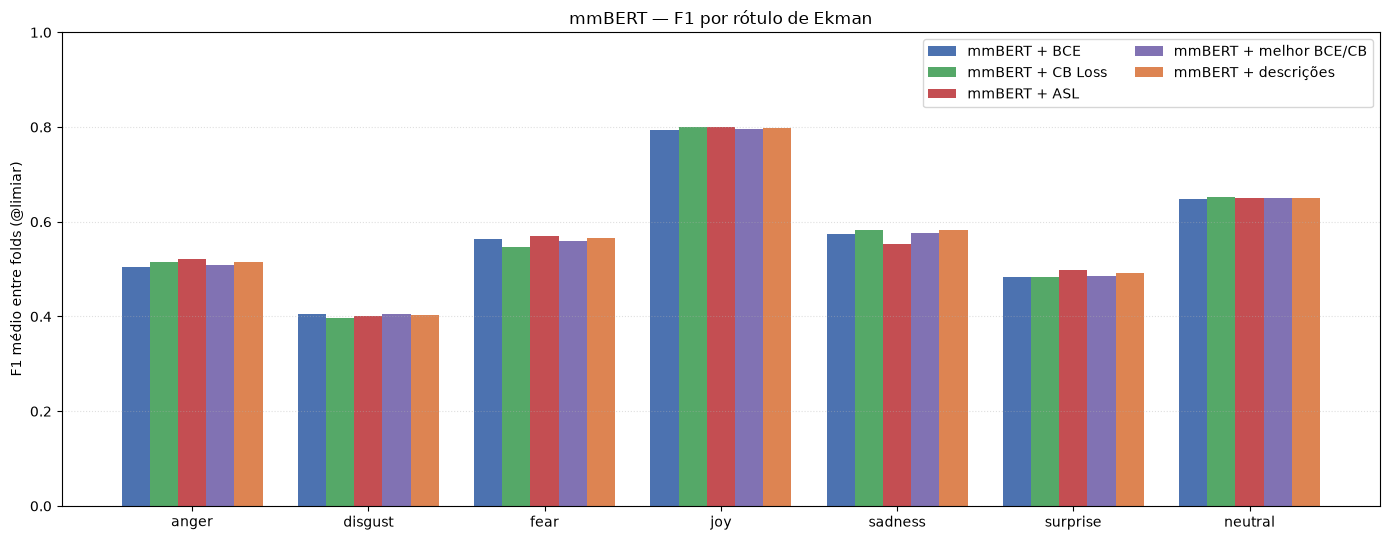

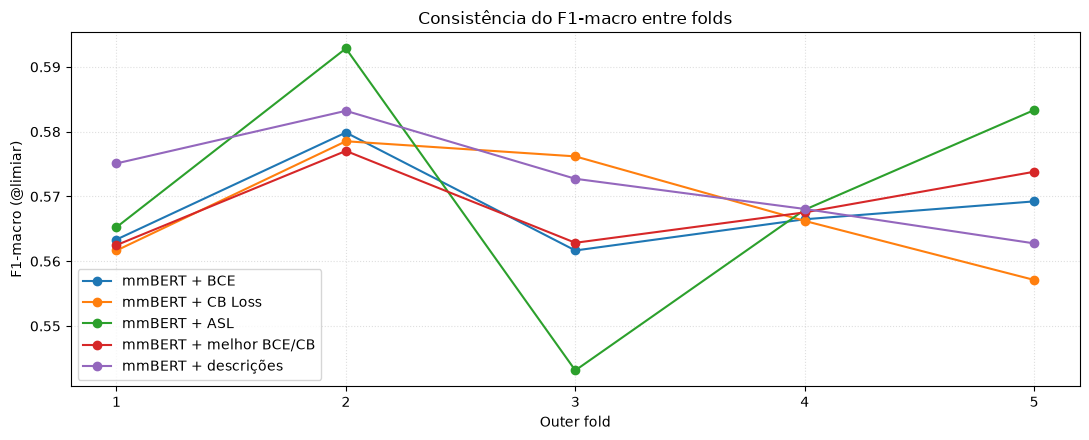

In [18]:
keys_to_plot = ["bce", "cb", "asl", "selected", "description"]
f1_per_label = {
    key: pd.DataFrame([metric["f1_per_label"] for metric in metrics_tuned[key]])
    .mean().reindex(EKMAN7)
    for key in keys_to_plot
}

x = np.arange(len(EKMAN7))
width = 0.16
fig, ax = plt.subplots(figsize=(14, 5.5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#DD8452"]
for index, key in enumerate(keys_to_plot):
    offset = (index - (len(keys_to_plot) - 1) / 2) * width
    ax.bar(
        x + offset, f1_per_label[key].values, width,
        label=DISPLAY_NAMES[key], color=colors[index],
    )
ax.set_xticks(x)
ax.set_xticklabels(EKMAN7)
ax.set_ylim(0, 1)
ax.set_ylabel("F1 médio entre folds (@limiar)")
ax.set_title("mmBERT — F1 por rótulo de Ekman")
ax.legend(ncol=2)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

fold_values = pd.DataFrame({
    DISPLAY_NAMES[key]: metric_frames[key]["f1_macro"]
    for key in keys_to_plot
})
ax = fold_values.plot(marker="o", figsize=(11, 4.5))
ax.set_xticks(range(1, N_OUTER_FOLDS + 1))
ax.set_xlabel("Outer fold")
ax.set_ylabel("F1-macro (@limiar)")
ax.set_title("Consistência do F1-macro entre folds")
ax.grid(linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


## Exportação

In [19]:
EXPORT_DIR = OUT_BASE / "mmbert_ekman_comparison"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

global_rows = []
for key, frame in metric_frames.items():
    for fold in frame.index:
        record = {
            "experiment": key,
            "model": DISPLAY_NAMES[key],
            "outer_fold": fold,
        }
        record.update({metric: frame.loc[fold, metric] for metric in SUMMARY_KEYS})
        global_rows.append(record)

pd.DataFrame(global_rows).to_csv(
    EXPORT_DIR / "mmbert_ekman_metrics_by_fold.csv", index=False
)
pd.DataFrame(f1_per_label).to_csv(
    EXPORT_DIR / "mmbert_ekman_f1_per_label.csv"
)
pd.concat({
    key: pd.DataFrame(thresholds_store[key], index=EKMAN7).T
    for key in thresholds_store
}, names=["experiment", "outer_fold"]).to_csv(
    EXPORT_DIR / "mmbert_ekman_thresholds.csv"
)
df_loss_selection.to_csv(EXPORT_DIR / "loss_selection_by_fold.csv")

summary = {
    "model": MODEL_NAME,
    "target": "Ekman direto — 6 grupos + neutral, multi-label",
    "experiments": {
        "bce": "cabeça linear + BCEWithLogitsLoss",
        "cb": "cabeça linear + Class-Balanced Loss (beta=0.9999)",
        "asl": "cabeça linear + ASL (gamma_neg=4, gamma_pos=1, clip=0.05)",
        "selected": "melhor entre BCE e CB por validação interna de cada fold",
        "description": "dual encoder compartilhado, descrição por rótulo e perda selecionada internamente",
    },
    "selected_loss_by_fold": SELECTED_LOSS_BY_FOLD,
    "fine_to_ekman": EKMAN_FROM_FINE,
    "ekman_to_sentiment": SENT_FROM_EKMAN,
    "results_tuned": {
        key: {
            metric: {
                "mean": float(frame[metric].mean()),
                "std": float(frame[metric].std()),
            }
            for metric in SUMMARY_KEYS
        }
        for key, frame in metric_frames.items()
    },
    "methodology": (
        "Outer CV com 5 folds; época e perda BCE/CB escolhidas por validação interna; "
        "cada OOF é produzido sem o respectivo fold de teste; limiares do fold k são "
        "calibrados somente nas probabilidades OOF dos folds diferentes de k."
    ),
    "description_note": (
        "A versão com descrições isola a visão instância-rótulo inspirada no TACO; "
        "não inclui as perdas CCL e LDL do TACO completo."
    ),
}

with open(EXPORT_DIR / "mmbert_ekman_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2, ensure_ascii=False)

print("Arquivos exportados para", EXPORT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))


Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\mmbert_ekman_comparison
{
  "model": "jhu-clsp/mmBERT-base",
  "target": "Ekman direto — 6 grupos + neutral, multi-label",
  "experiments": {
    "bce": "cabeça linear + BCEWithLogitsLoss",
    "cb": "cabeça linear + Class-Balanced Loss (beta=0.9999)",
    "asl": "cabeça linear + ASL (gamma_neg=4, gamma_pos=1, clip=0.05)",
    "selected": "melhor entre BCE e CB por validação interna de cada fold",
    "description": "dual encoder compartilhado, descrição por rótulo e perda selecionada internamente"
  },
  "selected_loss_by_fold": {
    "1": "bce",
    "2": "cb",
    "3": "bce",
    "4": "bce",
    "5": "bce"
  },
  "fine_to_ekman": {
    "anger": [
      "anger",
      "annoyance",
      "disapproval"
    ],
    "disgust": [
      "disgust"
    ],
    "fear": [
      "fear",
      "nervousness"
    ],
    "joy": [
      "admiration",
      "amusement",
      "approval",
  